<center><img src=https://images.squarespace-cdn.com/content/v1/591e58f72994cab66b93f891/1634663743264-139E1J5K08WAPEJ1YU3Z/Bayes+5.png width=800px></center>

# <center><b>naive Bayes⚙️</b></center>

**What you can expect from this notebook:** This notebook covers the main principles behind naive Bayes, a simple but quite frequently used classification algorithm based on **Bayes theorem**. Together with the theory a numpy implementation and a usage example are provided.

<div class="alert alert-block alert-info">👉If you're just interested in the complete, with comments documented implementation of a random forest regressor using just numpy and the copy module, feel free to click on show hidden code: </div>

In [1]:
class MixedDataNB:
    def __init__(self, like_dist_dict, laplace_smoothing=1):
        for dist in like_dist_dict.keys():
            if dist not in ['gaussian', 'multinomial']:
                raise ValueError(f'Found "{like_dist}" as like_dist parameter, please select one out of gaussian, multinomial, categorical')
        self.like_dist_dict = like_dist_dict
        self.laplace_smoothing = laplace_smoothing
        self.classes = []
        self.prior_probs = []
        self.likelihood = dict()
    def fit(self, X, y):
        #  compute & store prior clas probabilities
        self.classes, counts = np.unique(y, return_counts=True)
        self.prior_probs = counts / len(y)
        #  compute & store likelihood function
        for key, value in self.like_dist_dict.items():
            if key == 'gaussian':
                #  multivariate gaussian with diagonal cov matrix ~ multiplying many individual gaussians
                self.likelihood[key] = [scipy.stats.multivariate_normal(X[y==c][:, value].mean(axis=0), 
                                        X[y==c][:, value].var(axis=0) * np.eye(X[y==c][:, value].shape[-1])) for c in self.classes]
            if key == 'multinomial':
                #  calculate feature probabilities per class with laplace smoothing (additive smoothing)
                self.likelihood[key] = [(X[y==c][:, value].sum(axis=0) + self.laplace_smoothing) / 
                                        (X[y==c][:, value].sum(axis=0) + self.laplace_smoothing).sum() for c in self.classes]
    def predict(self, X):
        #  compute likelihood with shape (n_samples, n_classes)
        likelihood = np.ones((len(X), len(self.classes)))
        for key, value in self.likelihood.items():
            indices = self.like_dist_dict[key]
            if key == 'gaussian':
                likelihood *= np.stack([like.pdf(X[:, indices]) for like in self.likelihood[key]], axis=1)
            if key == 'multinomial':
                #  just proportional, dropped constant part of multinomial distribution
                likelihood *= np.stack([(p ** X[:, indices]).prod(axis=1) for p in self.likelihood[key]], axis=1)
        #  compute joined probability with shape (samples, classes) by multiplying likelihood with prior prob per class -> shape: (n_classes)
        j_p = likelihood * self.prior_probs
        #  make prediction by finding the class with the largest joined probability 
        return self.classes[np.argmax(j_p, axis=1)]

****
# <b>1 <span style="color:#ebd1a4">|</span> Intuition</b>

**Naive Bayes** is one of the simplest but also most frequently utilized family of probabilistic classifiers. It uses **Bayes theorem** to calculate the probability of each class given the data to then apply a decision rule. Usually the class with the highest probability is picked, this is also referred to **MAP(maximum a posteriori)-estimate** aka. picking the most probable hypothesis:<br>

<center>$\Large \hat{y} = \arg\max\limits_{k}p(C_k|x)$</center>

where:
* C_k are **possible outcomes** -> Classes
* x is the input vector **to be classified**

**The probability $p(C_k|x)$ can be obtained with Bayes theorem as explained in the next section.**

In [2]:
import numpy as np

#  class probabilities obtained by applying bayes theorem
labels = np.array(['A', 'B'])
probs = [0.6, 0.4]

#  MAP estimate
print(f'MAP estimate of example: {labels[np.argmax(probs)]}')

MAP estimate of example: A


****
# <b>2 <span style="color:#ebd1a4">|</span> Bayes theorem</b>
A short introduction to the core concept behind naive Bayes:

<center>$\Large p(C_k|x) = \frac{p(x|C_k)p(C_k)}{p(x)}\>\>\>$  <b>or in words:</b>  $\Large \>\>\> posterior = \frac{likelihood \cdot prior}{evidence}$</center>

<br> 

**Intuition:**
* The main idea is to **update a belief about the probability** of some event after having observed new evidence
* In the case of classification:
    * **Prior** belief about class probabilities for a new observation: **proportions of classes** obtained from training data
    * New **evidence** -> **features** of new observation
    * Bayes theorem allows updating the prior belief to obtain a **posterior** belief about class probabilities

**Mathematical realisation:**
* In the numerator, the **likelihood gets multiplied with the prior** probability.
    * The likelihood is essentially a conditional distribution but with the condition varying -> $p(x|C_k) \hat{=}  L(C_k|x)$.
    * When multiplying a conditional distribution with the pdf of its condition it results in a **joint distribution**.
    * **So the numerator of Bayes theorem results in a joint distribution of 2 variables x & C_k but with a fixed x**.
    

* The denominator is a **marginalization constant/the probability of the observed evidence occurring**.
    * It is used to turn the **joint probability** obtained from the numerator ($p(x, C_k)$) into a **conditional probability** ($p(C_k|x)$)
    * why this is necessary: the joint distribution integrates to 1 over both variables so when keeping one of them constant this isn't given anymore and it **wouldn't be a valid probability distribution** -> gets fixed by dividing by the joint pdf by the probability of one of its variables (here $p(x)$)


**generic example:**

In [3]:
"""
example:
- the chance of getting a rare illness is 0.1% -> prior
- you get a positive test result
    -> the test is right in 99% of cases 
- what's the chance of you realy having the illness?
"""
prior_prob = 0.001  # p(B)
likelihood = 0.99 # p(A|B)
evidence = 0.99 * 0.001 + 0.01 * 0.999  # p(A|B) * p(B) + p(A|~B) * p(~B) = p(A)

prior = (likelihood * prior_prob) / evidence
print(f'The probability of having the illness given the positive test result is {prior}.')

The probability of having the illness given the positive test result is 0.09016393442622951.


**classification example visualized:**

let's assume evidence with 1 continuous feature is observed and Bayes theorem is used to calculate the posterior probabilities for 2 classes A and B:
* prior probability obtained from training data: 70% A, 30%B
* likelihood: calculated under the assumption that the pdf of x given a class is normally distributed

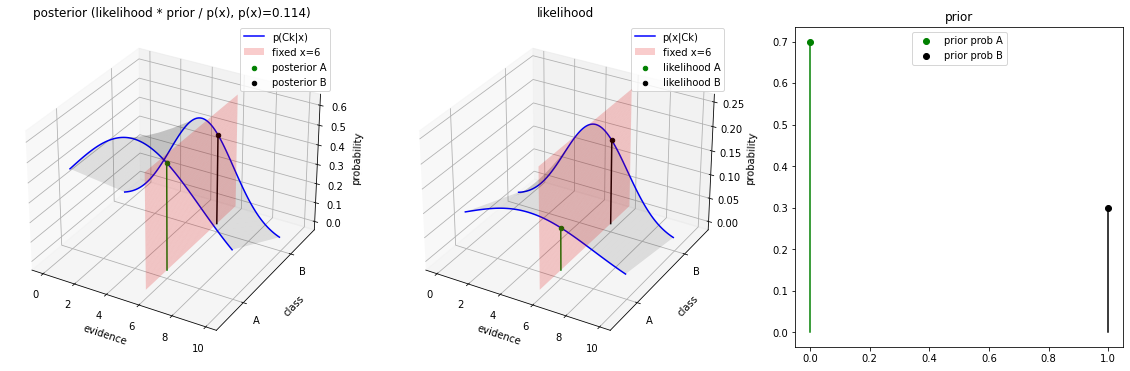

In [4]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

x_observed = 6

############## likelihood ##############
X = np.array([i/10 for i in range(100)])
p_x_given_A = scipy.stats.norm(4, 4).pdf(X)
p_x_given_B = scipy.stats.norm(5, 2).pdf(X)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(132, projection='3d')
ax.plot(X, np.zeros(X.shape), p_x_given_A, color='blue', label='p(x|Ck)')
ax.plot(X, np.ones(X.shape), p_x_given_B, color='blue')
ax.plot_surface(np.stack([X, X]), 
                np.stack([np.zeros(X.shape), np.ones(X.shape)]), 
                np.stack([p_x_given_A, p_x_given_B]), 
                color='black',
                alpha=0.1)

z_plane = np.array([i/400 for i in range(100)])
plane = ax.plot_surface(x_observed, np.stack([np.zeros(100)-0.4, np.ones(100)+0.4]), np.stack([z_plane, z_plane]), alpha=0.2, color='red', label='fixed x=6')
plane._facecolors2d=plane._facecolor3d
plane._edgecolors2d=plane._edgecolor3d
likelihood_A = scipy.stats.norm(4, 4).pdf(x_observed)
likelihood_B = scipy.stats.norm(5, 2).pdf(x_observed)
ax.scatter([x_observed], [0], [likelihood_A], color='green', label='likelihood A')
ax.plot([x_observed, x_observed], [0, 0], [0, likelihood_A], color='green')
ax.scatter([x_observed], [1], [likelihood_B], color='black', label='likelihood B')
ax.plot([x_observed, x_observed], [1, 1], [0, likelihood_B], color='black')
ax.legend()
ax.set_xlabel('evidence')
ax.set_ylabel('class')
ax.set_zlabel('probability')

locs, labels = plt.yticks()
plt.yticks(np.arange(2), ['A', 'B'])
ax.set_title('likelihood')

############## prior ##############
prior_A = 0.7
prior_B = 0.3
ax1 = fig.add_subplot(336)
ax1.plot([0, 0], [0, prior_A], color='green')
ax1.scatter([0], [prior_A], color='green', label='prior prob A')
ax1.plot([1, 1], [0, prior_B], color='black')
ax1.scatter([1], [prior_B], color='black', label='prior prob B')
ax1.legend(loc='upper center')
ax1.set_title('prior')

############## evidence ##############
evidence = likelihood_A * prior_A + likelihood_B * prior_B

############## posterior ##############
posterior_A = likelihood_A * prior_A / evidence
posterior_B = likelihood_B * prior_B / evidence
p_A_given_x = p_x_given_A * prior_A / evidence
p_B_given_x = p_x_given_B * prior_B / evidence

ax2 = fig.add_subplot(131, projection='3d')
ax2.plot(X, np.zeros(X.shape), p_A_given_x, color='blue', label='p(Ck|x)')
ax2.plot(X, np.ones(X.shape), p_B_given_x, color='blue')
ax2.plot_surface(np.stack([X, X]), 
                np.stack([np.zeros(X.shape), np.ones(X.shape)]), 
                np.stack([p_A_given_x, p_B_given_x]), 
                color='black',
                alpha=0.1)

z_plane = np.array([i/170 for i in range(100)])
plane = ax2.plot_surface(x_observed, np.stack([np.zeros(100)-0.4, np.ones(100)+0.4]), np.stack([z_plane, z_plane]), alpha=0.2, color='red', label='fixed x=6')
plane._facecolors2d=plane._facecolor3d
plane._edgecolors2d=plane._edgecolor3d
ax2.scatter([x_observed], [0], [posterior_A], color='green', label='posterior A')
ax2.plot([x_observed, x_observed], [0, 0], [0, posterior_A], color='green')
ax2.scatter([x_observed], [1], [posterior_B], color='black', label='posterior B')
ax2.plot([x_observed, x_observed], [1, 1], [0, posterior_B], color='black')
ax2.legend()
ax2.set_xlabel('evidence')
ax2.set_ylabel('class')
ax2.set_zlabel('probability')

locs, labels = plt.yticks()
plt.yticks(np.arange(2), ['A', 'B'])
ax2.set_title(f'posterior (likelihood * prior / p(x), p(x)={round(evidence, 3)})')

plt.show()

****
# <b>3 <span style="color:#ebd1a4">|</span> From bayes theorem to the naive bayes classifier</b>

To use Bayes theorem for classification, the process visualized above is extended to multidimensional evidence/features. Still, we calculate the class probabilities given the evidence **using Bayes theorem** as explained above to then apply the previously discussed **decision rule**.

Parts of Bayes theorem in classification context (the visualization above explained in more detail):
* $p(C_k)$ is the **prior** knowledge about the class probabilities. It can be calculated based on **class frequencies in the training data**.

* $p(x)$ is the total probability of observing the **evidence** x. Since it stays constant across classes it can be **ignored**.
    * Since this is just a linear scaling staying the same across classes it doesn't change the relationship between them. So the result of the **decision rule** stays the same
    * $\large p(C_k|x) \propto p(x|C_k)p(C_k)\>\>\>$ -> stays proportional when dropping p(x)
    
    
* $p(x|C_k)$ is the **likelihood** function of the classes given the evidence and with no doubt the **hardest part to calculate**

As shown above, it stays quite simple when limiting the observation to 1 feature, but when increasing that number we run into the curse of dimensionality quite soon. Naive Bayes makes one assumption to simplify this calculation, which is responsible for its name "**naive**":
> **Conditional independence between the features.**

Under this assumption $p(x|C_k) = p(x_1, x_2, ..., x_n|C_k)$ can be written as $p(x|C_k) = p(x_1|C_k)p(x_2|C_k)...p(x_n|C_k)$. In practice that means to compute the likelihood of observing each class given the whole evidence we just have to compute the individual likelihoods of the classes given individual features and multiply them all together.

So the classifier formulated in the beginning...: 

<center>$\Large \hat{y} = \arg\max\limits_{k}p(C_k|x)$</center>

... now can be specified as:

<center>$\Large \hat{y} = \arg\max\limits_{k}p(C_k)\prod\limits_{i}p(x_i|C_k)$</center>

****
# <b>4 <span style="color:#ebd1a4">|</span> Different naive Bayes algorithms - the importance of the likelihood</b>
**The different variants of naive Bayes mainly differ in the computation of the likelihood $p(x_i|C_k)$.** The most common choices will be covered in this section.

As shown in the last visualization the **likelihood of each class is obtained by plugging in the observed evidence in its pdf given each class**. In the example, the feature x was assumed to follow a **gaussian** distribution. But depending on the type of feature, this changes.

Still the main idea behind calculating the likelihood stays the same: 
1. **Figure out the underlying distribution of your features**
2. **Split the training data based on class labels**
3. **With every resulting data subset 'fit' a distribution to every feature of the corresponding class**
4. **Use these ditributions to calculate the likelihood term as described above**

**Most common distributions:**
To keep things short the formulas aren't provided in this notebook, I suggest checking out the corresponding Wikipedia articles for more detailed information.
* **Gaussian**
    * used for **continuous features**
    * shown in the last visualization
* **Binomial**
    * used for **binary features**
* **Categorical**
    * used for **categorical features**
* **Multinomial**
    * used for both, **binary features** & **categorical features**
        * -> generalization of Binomial & Categorical
    * **important addition:** Laplace **smoothing**
        * additive smoothing means adding 1 to each category count in the training data to ensure no probability will be 0
        * --> when multiplying a chain of probabilities and one of them is zero, the entire result is zero

****
# <b>5 <span style="color:#ebd1a4">|</span> Python implementation</b>

**libraries used:**

In [5]:
#  for implementation
import numpy as np  # linear algebra
import scipy  # probability distributions

#  used for data handeling and visualisation
import pandas as pd # loading and transforming data
import matplotlib.pyplot as plt # visualisations
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # creating & visualising confusion matrices
from sklearn.model_selection import train_test_split # splitting data in train/test set

**basic nb classifier:**

In [6]:
class NaiveBayes:
    def __init__(self, like_dist='gaussian', laplace_smoothing=1):
        if like_dist in ['gaussian', 'multinomial']:
            self.like_dist = like_dist
        else:
            raise ValueError(f'Found "{like_dist}" as like_dist parameter, please select one out of gaussian, multinomial, categorical')
        self.laplace_smoothing = laplace_smoothing
        self.classes = []
        self.prior_probs = []
        self.likelihood = []
    def fit(self, X, y):
        #  compute & store prior clas probabilities
        self.classes, counts = np.unique(y, return_counts=True)
        self.prior_probs = counts / len(y)
        #  compute & store likelihood function
        if self.like_dist == 'gaussian':
            #  multivariate gaussian with diagonal cov matrix ~ multiplying many individual gaussians
            self.likelihood = [scipy.stats.multivariate_normal(X[y==c].mean(axis=0), 
                                                               X[y==c].var(axis=0) * np.eye(X[y==c].shape[-1])) for c in self.classes]
        if self.like_dist == 'multinomial':
            #  calculate feature probabilities per class with laplace smoothing (additive smoothing)
            self.likelihood = [(X[y==c].sum(axis=0) + self.laplace_smoothing) / 
                               (X[y==c].sum(axis=0) + self.laplace_smoothing).sum() for c in self.classes]
    def predict(self, X):
        #  compute likelihood with shape (n_samples, n_classes)
        if self.like_dist == 'gaussian':
            likelihood = np.stack([like.pdf(X) for like in self.likelihood], axis=1)
        if self.like_dist == 'multinomial':
            #  just proportional, dropped constant part of multinomial distribution
            likelihood = np.stack([(p ** X).prod(axis=1) for p in self.likelihood], axis=1)
        #  compute joined probability with shape (samples, classes) by multiplying likelihood with prior prob per class -> shape: (n_classes)
        j_p = likelihood * self.prior_probs
        #  make prediction by finding the class with the largest joined probability 
        return self.classes[np.argmax(j_p, axis=1)]

Since the conditional independence assumption allows for constructing the likelihood from the individual feature likelihoods, we aren't limited to using the same distribution for every feature. Here is an implementation for **mixed data**:

In [7]:
class MixedDataNB:
    def __init__(self, like_dist_dict, laplace_smoothing=1):
        for dist in like_dist_dict.keys():
            if dist not in ['gaussian', 'multinomial']:
                raise ValueError(f'Found "{like_dist}" as like_dist parameter, please select one out of gaussian, multinomial, categorical')
        self.like_dist_dict = like_dist_dict
        self.laplace_smoothing = laplace_smoothing
        self.classes = []
        self.prior_probs = []
        self.likelihood = dict()
    def fit(self, X, y):
        #  compute & store prior clas probabilities
        self.classes, counts = np.unique(y, return_counts=True)
        self.prior_probs = counts / len(y)
        #  compute & store likelihood function
        for key, value in self.like_dist_dict.items():
            if key == 'gaussian':
                #  multivariate gaussian with diagonal cov matrix ~ multiplying many individual gaussians
                self.likelihood[key] = [scipy.stats.multivariate_normal(X[y==c][:, value].mean(axis=0), 
                                        X[y==c][:, value].var(axis=0) * np.eye(X[y==c][:, value].shape[-1])) for c in self.classes]
            if key == 'multinomial':
                #  calculate feature probabilities per class with laplace smoothing (additive smoothing)
                self.likelihood[key] = [(X[y==c][:, value].sum(axis=0) + self.laplace_smoothing) / 
                                        (X[y==c][:, value].sum(axis=0) + self.laplace_smoothing).sum() for c in self.classes]
    def predict(self, X):
        #  compute likelihood with shape (n_samples, n_classes)
        likelihood = np.ones((len(X), len(self.classes)))
        for key, value in self.likelihood.items():
            indices = self.like_dist_dict[key]
            if key == 'gaussian':
                likelihood *= np.stack([like.pdf(X[:, indices]) for like in self.likelihood[key]], axis=1)
            if key == 'multinomial':
                #  just proportional, dropped constant part of multinomial distribution
                likelihood *= np.stack([(p ** X[:, indices]).prod(axis=1) for p in self.likelihood[key]], axis=1)
        #  compute joined probability with shape (samples, classes) by multiplying likelihood with prior prob per class -> shape: (n_classes)
        j_p = likelihood * self.prior_probs
        #  make prediction by finding the class with the largest joined probability 
        return self.classes[np.argmax(j_p, axis=1)]

****
# <b>6 <span style="color:#ebd1a4">|</span> Classification on titanic dataset</b>

**prepare data:**

In [8]:
titanic_data = pd.read_csv("../input/titanic/train.csv", usecols=["Survived", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]).dropna()
titanic_data["Sex"] = titanic_data["Sex"].astype("category").cat.codes
titanic_data["Embarked"] = titanic_data["Embarked"].astype("category").cat.codes

features = titanic_data[['Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Fare']].to_numpy() # select everything but the target
labels = titanic_data.loc[:, "Survived"].to_numpy() # select the target

X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2)

titanic_data.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,1,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,0,1,35.0,0,0,8.0500,2


In [9]:
X_train

array([[ 0. , 24. ,  0. ,  2. ,  2. , 16.7],
       [ 0. , 45. ,  1. ,  4. ,  2. , 27.9],
       [ 1. , 47. ,  0. ,  0. ,  2. , 38.5],
       ...,
       [ 0. , 22. ,  0. ,  1. ,  2. , 55. ],
       [ 0. , 24. ,  0. ,  0. ,  0. , 69.3],
       [ 0. , 32. ,  0. ,  0. ,  2. , 13. ]])

**fit & evaluate:**
* Mixed naive bayes
    * multinomial likelihood for discrete features 
    * gaussian likelihood for continous feature
   

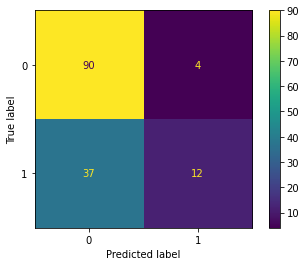

accuracy = 0.7132867132867133,
recall = 0.24489795918367346,
precision = 0.75,
f1-score = 0.3692307692307692


In [10]:
nb = MixedDataNB({'multinomial':[i for i in range(5)], 'gaussian':[5]})
nb.fit(X_train, y_train)

#  make predictions:
predictions = nb.predict(X_val)

#  confusion matrix
cm = confusion_matrix(y_val, predictions, labels=[0, 1])
cm_displ = ConfusionMatrixDisplay(cm)
cm_displ.plot()
plt.show()

#  calculate accuracy:
accuracy = np.mean(predictions==y_val)

#  calculate recall:
recall = cm[1, 1]/cm[1, :].sum() # of the total actual positives, how much were classified correctly

#  calculate precision:
precision = cm[1, 1]/cm[:, 1].sum() # of all predicted positives, how much were True positives

#  not that neccessary for this problem, but for the completeness:
f1 = 2 * ((recall * precision)/(recall + precision)) 

print(f"accuracy = {accuracy},\nrecall = {recall},\nprecision = {precision},\nf1-score = {f1}")

**That's all for this notebook, have a great day and happy learning!👋**

*If you liked that kind of notebook, I've made quite a handful of similar ones that can be found here: [ml from scratch: table of contents](https://www.kaggle.com/discussions/general/334676)*